In [1]:
import os
import pyproj

os.environ["PROJ_LIB"] = pyproj.datadir.get_data_dir()

print(os.environ["PROJ_LIB"])

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyproj\proj_dir\share\proj


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
import contextily as ctx
import folium
import matplotlib.colors as colors

## Chicago Crash Dataset

This notebook analyzes Chicago traffic crash records and focuses on recent years to keep the clustering and map rendering manageable.

In [3]:
df = pd.read_csv(r'C:\Users\HP\Downloads\Traffic_Crashes_-_Crashes_20250420.csv')

df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"])

df = df[df["CRASH_DATE"].dt.year >= 2024]

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 142160 entries, 0 to 936809
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   CRASH_RECORD_ID                142160 non-null  str           
 1   CRASH_DATE_EST_I               9216 non-null    str           
 2   CRASH_DATE                     142160 non-null  datetime64[us]
 3   POSTED_SPEED_LIMIT             142160 non-null  int64         
 4   TRAFFIC_CONTROL_DEVICE         142160 non-null  str           
 5   DEVICE_CONDITION               142160 non-null  str           
 6   WEATHER_CONDITION              142160 non-null  str           
 7   LIGHTING_CONDITION             142160 non-null  str           
 8   FIRST_CRASH_TYPE               142160 non-null  str           
 9   TRAFFICWAY_TYPE                142160 non-null  str           
 10  LANE_CNT                       18 non-null      float64       
 11  ALIGNMENT       

In [5]:
df.head()

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,01184614b08579d6befa7734427e750d0f10e79dc0aa42...,NaN,2025-04-04 01:57:00,15,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",ANGLE,PARKING LOT,...,0.0,0.0,2.0,0.0,1,6,4,41.766021,-87.572442,POINT (-87.572442196614 41.766020695126)
1,00a530520c84927490b597a6220ff3f2a3347472ef3086...,NaN,2025-01-15 13:50:00,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,FIXED OBJECT,RAMP,...,0.0,0.0,1.0,0.0,13,4,1,41.816073,-87.656743,POINT (-87.656742699936 41.816073475493)
2,019d84ab0f03ace0b07075b0a7d83ba867b7dadad30410...,Y,2025-03-29 18:10:00,35,STOP SIGN/FLASHER,NO CONTROLS,RAIN,DAYLIGHT,ANGLE,NOT DIVIDED,...,0.0,1.0,4.0,0.0,18,7,3,41.793739,-87.697311,POINT (-87.697311324011 41.793738897511)
3,03a3b86d3b62c8948e25623db7ccf326fed99eaa297b59...,NaN,2025-03-15 00:01:00,30,NO CONTROLS,NO CONTROLS,RAIN,"DARKNESS, LIGHTED ROAD",PARKED MOTOR VEHICLE,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,1.0,0.0,0,7,3,41.836784,-87.723610,POINT (-87.723610276569 41.836784034697)
4,088061d9b7e5ab5b1353517ebefcadca065c20de8ca860...,N,2025-03-15 14:12:00,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,UNKNOWN,UNKNOWN,PEDALCYCLIST,FOUR WAY,...,0.0,0.0,2.0,0.0,14,7,3,41.871778,-87.625789,POINT (-87.625789124419 41.871778332743)


## Remove Missing Coordinates

Rows with null latitude or longitude are dropped because spatial clustering requires valid coordinate pairs for every record.

In [6]:
df = df.dropna(subset=['LATITUDE', 'LONGITUDE'])

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 140623 entries, 0 to 936809
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   CRASH_RECORD_ID                140623 non-null  str           
 1   CRASH_DATE_EST_I               9143 non-null    str           
 2   CRASH_DATE                     140623 non-null  datetime64[us]
 3   POSTED_SPEED_LIMIT             140623 non-null  int64         
 4   TRAFFIC_CONTROL_DEVICE         140623 non-null  str           
 5   DEVICE_CONDITION               140623 non-null  str           
 6   WEATHER_CONDITION              140623 non-null  str           
 7   LIGHTING_CONDITION             140623 non-null  str           
 8   FIRST_CRASH_TYPE               140623 non-null  str           
 9   TRAFFICWAY_TYPE                140623 non-null  str           
 10  LANE_CNT                       18 non-null      float64       
 11  ALIGNMENT       

## Folium Plotting Function

Defines a reusable map function that colors each crash point by cluster label and renders noise points in light gray.

In [8]:

def plot_clusters_folium(df):

    # Keep coordinates in EPSG:4326
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["LONGITUDE"], df["LATITUDE"]),
        crs="EPSG:4326"
    )

    # Center the map
    center = [
        gdf["LATITUDE"].mean(),
        gdf["LONGITUDE"].mean()
    ]

    m = folium.Map(
        location=center,
        zoom_start=11,
        tiles="CartoDB Positron"
    )

    # Create colours
    unique_clusters = sorted(
        gdf[gdf["Cluster"] != -1]["Cluster"].unique()
    )

    n_colors = max(len(unique_clusters), 1)
    cmap = colormaps.get_cmap("tab20").resampled(n_colors)

    cluster_colors = {
        cluster: colors.to_hex(cmap(i))
        for i, cluster in enumerate(unique_clusters)
    }

    # Plot every point
    for _, row in gdf.iterrows():

        if row["Cluster"] == -1:
            color = "lightgray"
        else:
            color = cluster_colors[row["Cluster"]]

        folium.CircleMarker(
            location=[row["LATITUDE"], row["LONGITUDE"]],
            radius=2,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            weight=0,
            popup=f"Cluster: {row['Cluster']}"
        ).add_to(m)

    return m


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 140623 entries, 0 to 936809
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   CRASH_RECORD_ID                140623 non-null  str           
 1   CRASH_DATE_EST_I               9143 non-null    str           
 2   CRASH_DATE                     140623 non-null  datetime64[us]
 3   POSTED_SPEED_LIMIT             140623 non-null  int64         
 4   TRAFFIC_CONTROL_DEVICE         140623 non-null  str           
 5   DEVICE_CONDITION               140623 non-null  str           
 6   WEATHER_CONDITION              140623 non-null  str           
 7   LIGHTING_CONDITION             140623 non-null  str           
 8   FIRST_CRASH_TYPE               140623 non-null  str           
 9   TRAFFICWAY_TYPE                140623 non-null  str           
 10  LANE_CNT                       18 non-null      float64       
 11  ALIGNMENT       

## Filter Zero Coordinates

This step removes records where latitude or longitude equals zero, which usually indicates invalid geolocation values.

In [10]:
df = df[df['LATITUDE'] != 0]
df = df[df['LONGITUDE'] != 0]


In [11]:
df[['LATITUDE', 'LONGITUDE']].describe()

,LATITUDE,LONGITUDE
count,140614.000000,140614.000000
mean,41.860022,-87.680232
std,0.086411,0.058925
min,41.644670,-87.917163
25%,41.787388,-87.722438
50%,41.876245,-87.676015
75%,41.927758,-87.635558
max,42.022780,-87.524587


In [12]:
df[['LATITUDE', 'LONGITUDE']].info()

<class 'pandas.DataFrame'>
Index: 140614 entries, 0 to 936809
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   LATITUDE   140614 non-null  float64
 1   LONGITUDE  140614 non-null  float64
dtypes: float64(2)
memory usage: 3.2 MB


In [13]:
df.tail()

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
936805,969bd7fa2d19eabbaeb5e7e25124087945cfd99a4e32a2...,NaN,2025-01-27 07:00:00,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,...,0.0,0.0,2.0,0.0,7,2,1,41.883098,-87.633134,POINT (-87.633134156843 41.88309798438)
936806,5f3265aec2ae9cb1e601fe0a0b4af11191b55d8786a26c...,NaN,2025-01-28 15:50:00,40,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN BARRIER,...,0.0,0.0,2.0,0.0,15,3,1,41.903788,-87.624720,POINT (-87.624720160474 41.903788026488)
936807,00580c38c361fe6da401a2a6b96f381a08f3a6811f18c7...,NaN,2025-01-29 19:25:00,30,NO CONTROLS,NO CONTROLS,CLEAR,"DARKNESS, LIGHTED ROAD",REAR END,PARKING LOT,...,0.0,0.0,2.0,0.0,19,4,1,41.988314,-87.791671,POINT (-87.791671453941 41.988313831775)
936808,4f4333f00f578df2ffc68daa7a1177143340d8d899b83c...,NaN,2025-01-29 09:27:00,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,DAYLIGHT,REAR END,FOUR WAY,...,0.0,0.0,2.0,0.0,9,4,1,41.852500,-87.666172,POINT (-87.666172373715 41.852500328787)
936809,5ac09423aa9016c9755f1cace10a067fcab2648f18577c...,NaN,2025-01-29 19:08:00,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,CLEAR,"DARKNESS, LIGHTED ROAD",PEDESTRIAN,FOUR WAY,...,1.0,0.0,1.0,0.0,19,4,1,41.885802,-87.624660,POINT (-87.624659771063 41.885801546318)


### Latitude/Longitude input for HDBSCAN (coords)

- Raw columns are in geographic coordinates (EPSG:4326):
  - LONGITUDE = x-axis
  - LATITUDE = y-axis
- points_from_xy(LONGITUDE, LATITUDE) creates geometry as (x, y) = (lon, lat).
- gdf = gdf.to_crs(utm) converts those points to a projected CRS (UTM), so units become meters.
- coords = np.column_stack([gdf.geometry.x, gdf.geometry.y]) produces a numeric matrix of shape (n_points, 2):
  - column 0: projected easting (x)
  - column 1: projected northing (y)
- With metric='euclidean', this setup is appropriate because distance is measured in meter units.
- Practical interpretation: min_cluster_size and min_samples are then neighborhood density thresholds in projected space, not in degrees.

In [14]:
# df_loc = (
#     df[['LATITUDE', 'LONGITUDE']]
#     .apply(lambda s: s.astype(str).str.replace(',', '', regex=False))
#     .astype(float)
# )

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df["LONGITUDE"],
        df["LATITUDE"]
    ),
    crs="EPSG:4326"
)

In [15]:
utm = gdf.estimate_utm_crs()

gdf = gdf.to_crs(utm)

In [16]:
coords = np.column_stack([
    gdf.geometry.x,
    gdf.geometry.y
])

## HDBSCAN Clustering

Runs HDBSCAN on projected coordinates to detect dense crash hotspots and label sparse points as noise (-1).

In [17]:
#coords_scaled = df_loc.copy()
#coords_scaled['LATITUDE'] = 2*coords_scaled['LATITUDE']

import hdbscan

hdb = hdbscan.HDBSCAN(min_samples=15, min_cluster_size=100, metric='euclidean')
labels = hdb.fit_predict(coords)

In [18]:
df['Cluster'] = hdb.fit_predict(coords)  

df['Cluster'].value_counts()

Cluster
-1      55601
 102     1009
 101      897
 82       794
 220      717
        ...  
 358      101
 95       101
 135      101
 364      101
 167      100
Name: count, Length: 372, dtype: int64

In [19]:
df['Cluster']

0         125
1          -1
2         143
3         212
4         347
         ... 
936805    355
936806     -1
936807     -1
936808    233
936809    359
Name: Cluster, Length: 140614, dtype: int64

In [20]:
df['Cluster'].sum()

np.int64(15608500)

## Noise Count

Counts how many crashes were assigned to noise (cluster label -1), which helps assess how strict the clustering is.

In [21]:
Cluster_count = df.groupby('Cluster').Cluster.count()
Cluster_count_noise  = Cluster_count[Cluster_count.index == -1]
Cluster_count_noise

Cluster
-1    55601
Name: Cluster, dtype: int64

## Total Crash Records

Reports the final number of crash rows used after cleaning and coordinate filtering.

In [22]:
len(df)

140614

## Cluster Evaluation and Analysis

Summarizes cluster size distribution to check whether detected hotspots are balanced or dominated by a few large groups.

In [23]:
cluster_sizes = (
    df[df["Cluster"] != -1]
    .groupby("Cluster")
    .size()
)

print(cluster_sizes.describe())

count     371.000000
mean      229.145553
std       127.916634
min       100.000000
25%       138.000000
50%       193.000000
75%       284.500000
max      1009.000000
dtype: float64


## Cluster Sizes

Lists the largest non-noise clusters and prepares a subset of top clusters for mapping and further inspection.

In [24]:
cluster_sizes = (df[df['Cluster'] != -1].groupby('Cluster').size().sort_values(ascending=False))
top_clusters = cluster_sizes.head(500).index
print(cluster_sizes.head(10))

Cluster
102    1009
101     897
82      794
220     717
237     677
183     652
73      584
87      566
293     560
335     553
dtype: int64


## Cluster Point Mapping

Plots crashes from the selected top clusters on an interactive Folium map and saves the output as HTML.

In [25]:
top_clusters = df[df['Cluster'].isin(top_clusters)]

m = plot_clusters_folium(top_clusters)
m.save("hdbscan_clusters_2025.html")

In [26]:
cluster_sizes.describe()

count     371.000000
mean      229.145553
std       127.916634
min       100.000000
25%       138.000000
50%       193.000000
75%       284.500000
max      1009.000000
dtype: float64

## Crashes Per Cluster

Uses a histogram to visualize how many crashes belong to each cluster label.

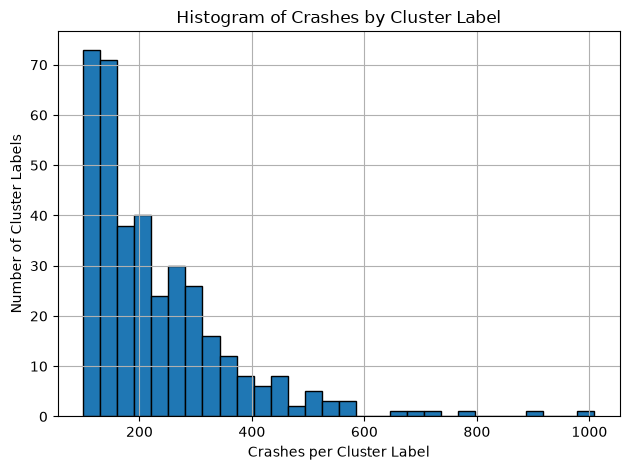

In [27]:
ax = cluster_sizes.hist(bins=30, edgecolor='black')
ax.set_title('Histogram of Crashes by Cluster Label')
ax.set_xlabel('Crashes per Cluster Label')
ax.set_ylabel('Number of Cluster Labels')
plt.tight_layout()

In [28]:
import os
print(os.getcwd())

c:\Users\HP\OneDrive\Desktop\Cali


## Open Cluster Map in Browser

Builds the absolute path to the saved HTML map and launches it in your default web browser.

In [36]:
import webbrowser

filepath = os.path.abspath("hdbscan_clusters_2025.html")
webbrowser.open("file://" + filepath)

True

## Cluster Quality Metrics

Evaluates non-noise clusters using silhouette score and Davies-Bouldin score to quantify separation and compactness.

In [30]:
mask = labels != -1

silhouette_score(
    coords[mask],
    labels[mask]
)

0.4809115987718131

In [31]:
davies_bouldin_score(
    coords[mask],
    labels[mask]
)

0.6519396969986394

## Most Common Attributes Per Cluster

Aggregates each non-noise cluster to summarize typical conditions, such as speed limit, lighting, and traffic control context.

In [32]:
def most_common(x):
    m = x.mode(dropna=True)
    return m.iloc[0] if not m.empty else np.nan

cluster_stats = (
    df[df["Cluster"] != -1]
    .groupby("Cluster")
    .agg(
        Crashes=("Cluster","size"),
        Mean_Lat=("LATITUDE","mean"),
        Mean_Lon=("LONGITUDE","mean"),
        Most_Common_Speed_Limit=("POSTED_SPEED_LIMIT", most_common),
        Most_Common_Light_Condition=("LIGHTING_CONDITION", most_common),
        Traffic_control=("TRAFFIC_CONTROL_DEVICE", most_common),
        Device_condition=("DEVICE_CONDITION", most_common),
        Injury_total=("INJURIES_TOTAL", most_common)
    )
    .sort_values("Crashes", ascending=False)
)

print(cluster_stats.head(10))

         Crashes   Mean_Lat   Mean_Lon  Most_Common_Speed_Limit  \
Cluster                                                           
102         1009  41.771955 -87.663777                       30   
101          897  41.808199 -87.665923                       30   
82           794  41.793685 -87.776658                       30   
220          717  41.944849 -87.667590                       30   
237          677  41.874703 -87.686047                       30   
183          652  41.867257 -87.642593                       30   
73           584  41.943831 -87.808814                       30   
87           566  41.765522 -87.619200                       30   
293          560  41.903001 -87.724384                       30   
335          553  41.952259 -87.646586                       30   

        Most_Common_Light_Condition Traffic_control Device_condition  \
Cluster                                                                
102                        DAYLIGHT     NO CONTROLS

In [33]:
import os

size_mb = os.path.getsize("hdbscan_clusters_2025.html") / (1024*1024)
print(f"{size_mb:.2f} MB")

84.20 MB


In [35]:
import pyproj
print(pyproj.datadir.get_data_dir())

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyproj\proj_dir\share\proj
